# 06 · Delivery performance

Estimated vs. actual delivery time by state, plus a geographic view
using the state centroids built in notebook 03.

In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

In [2]:
orders = pd.read_parquet(PROCESSED / "orders_clean.parquet")
geo_state = pd.read_csv(PROCESSED / "geolocation_state_centroids.csv")

delivered = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"].notna())
].copy()

national = {
    "n_delivered_orders": int(len(delivered)),
    "avg_delivery_days": round(delivered["delivery_days"].mean(), 2),
    "median_delivery_days": round(delivered["delivery_days"].median(), 2),
    "std_delivery_days": round(delivered["delivery_days"].std(), 2),
    "avg_estimate_days": round(delivered["estimate_days"].mean(), 2),
    "pct_late": round((delivered["is_late"]).mean() * 100, 2),
    "avg_days_early_vs_estimate": round(delivered["days_early_vs_estimate"].mean(), 2),
}
print("National delivery performance:")
for k, v in national.items():
    print(f"  {k}: {v}")

National delivery performance:
  n_delivered_orders: 96470
  avg_delivery_days: 12.56
  median_delivery_days: 10.22
  std_delivery_days: 9.55
  avg_estimate_days: 23.74
  pct_late: 8.11
  avg_days_early_vs_estimate: 11.18


In [3]:
by_state = delivered.groupby("customer_state").agg(
    n_orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_days_early_vs_estimate=("days_early_vs_estimate", "mean"),
    pct_late=("is_late", lambda s: s.mean() * 100),
    avg_review_score=("review_score", "mean"),
).reset_index().rename(columns={"customer_state": "state"})
by_state = by_state.sort_values("avg_delivery_days", ascending=False)
by_state.to_csv(RESULTS / "delivery_by_state.csv", index=False)

print(f"Slowest state: {by_state.iloc[0]['state']} ({by_state.iloc[0]['avg_delivery_days']:.1f}d avg)")
print(f"Fastest state: {by_state.iloc[-1]['state']} ({by_state.iloc[-1]['avg_delivery_days']:.1f}d avg)")

Slowest state: RR (29.4d avg)
Fastest state: SP (8.8d avg)


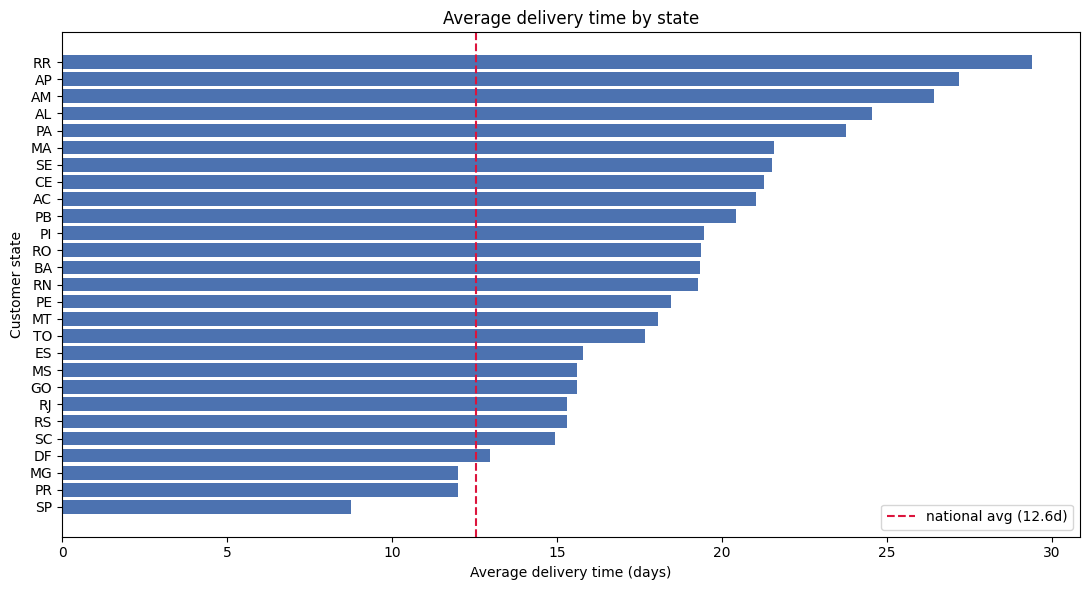

In [4]:
plt.figure(figsize=(11, 6))
plt.barh(by_state["state"], by_state["avg_delivery_days"], color="#4C72B0")
plt.axvline(national["avg_delivery_days"], color="crimson", linestyle="--",
            label=f"national avg ({national['avg_delivery_days']:.1f}d)")
plt.xlabel("Average delivery time (days)")
plt.ylabel("Customer state")
plt.title("Average delivery time by state")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Delivery map
Interactive Plotly map, state centroid bubbles sized by order volume.

In [5]:
map_df = by_state.merge(geo_state, on="state", how="left")
fig = px.scatter_geo(
    map_df,
    lat="lat", lon="lng",
    size="n_orders",
    color="avg_delivery_days",
    hover_name="state",
    hover_data={"avg_delivery_days": ":.1f", "pct_late": ":.1f", "n_orders": True,
                "lat": False, "lng": False},
    color_continuous_scale="OrRd",
    scope="south america",
    title="Delivery time by state (bubble size = order volume)",
)
fig.update_geos(center=dict(lat=-14, lon=-52), projection_scale=4, showcountries=True)
fig.show()

In [6]:
with open(RESULTS / "delivery_summary.json", "w") as f:
    json.dump({
        "national": national,
        "slowest_state": by_state.iloc[0].to_dict(),
        "fastest_state": by_state.iloc[-1].to_dict(),
    }, f, indent=2, default=str)

print("Saved: results/delivery_by_state.csv, results/delivery_summary.json")

Saved: results/delivery_by_state.csv, results/delivery_summary.json
